In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/6
    print("準備完了！このまま下のセルを実行できます。")

# 6.1 & 6.2 双対表現とカーネル関数の構成 (Dual Representations and Kernel Construction)

本ノートブックでは、高次元特徴空間における線形モデルを、データ間の内積のみを通じて効率的に計算可能にする**カーネル法 (Kernel Methods)** の基礎を学びます。
主問題（重み空間 $\mathbf{w}$ の最適化）から双対問題（Gram行列 $\mathbf{K}$ によるサンプル空間の最適化）への変換原理（表現定理）、特徴次元 $M$ とサンプルサイズ $N$ の計算量比較、Mercerの定理に基づく有効なカーネル構築法則、および基底関数の重ね合わせからカーネル関数が形作られるメカニズム（**PRML Figure 6.1**）を完全実装・可視化します。

## 6.1 双対表現 (Dual Representations) と表現定理

線形回帰の正則化二乗和誤差関数
$$ J(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) - t_n)^2 + \frac{\lambda}{2} \mathbf{w}^T \mathbf{w} $$
の勾配を 0 と置くと：
$$ \nabla J(\mathbf{w}) = \sum_{n=1}^N (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) - t_n) \boldsymbol{\phi}(\mathbf{x}_n) + \lambda \mathbf{w} = \mathbf{0} $$
$$ \mathbf{w} = -\frac{1}{\lambda} \sum_{n=1}^N (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) - t_n) \boldsymbol{\phi}(\mathbf{x}_n) = \sum_{n=1}^N a_n \boldsymbol{\phi}(\mathbf{x}_n) = \mathbf{\Phi}^T \mathbf{a} $$
ここで $a_n \equiv -\frac{1}{\lambda}(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) - t_n)$ です。
この関係式は、**最適解 $\mathbf{w}$ が常に学習データ点の特徴ベクトル $\boldsymbol{\phi}(\mathbf{x}_n)$ の線形結合として完全に表現できる**こと（表現定理: Representer Theorem）を示しています！

### 双対目的関数と Gram 行列
$\mathbf{w} = \mathbf{\Phi}^T \mathbf{a}$ を元の誤差関数に代入すると、$\mathbf{a}$ に関する双対誤差関数が得られます：
$$ J(\mathbf{a}) = \frac{1}{2} \mathbf{a}^T \mathbf{K} \mathbf{K} \mathbf{a} - \mathbf{a}^T \mathbf{K} \mathbf{t} + \frac{1}{2}\mathbf{t}^T \mathbf{t} + \frac{\lambda}{2} \mathbf{a}^T \mathbf{K} \mathbf{a} $$
ここで $\mathbf{K} = \mathbf{\Phi}\mathbf{\Phi}^T$ は $N \times N$ の **Gram 行列** であり、要素はカーネル関数
$$ K_{nm} = \boldsymbol{\phi}(\mathbf{x}_n)^T \boldsymbol{\phi}(\mathbf{x}_m) = k(\mathbf{x}_n, \mathbf{x}_m) $$
で与えられます。
$\mathbf{a}$ について勾配を 0 と置くことで、双対解が得られます：
$$ \mathbf{a} = (\mathbf{K} + \lambda \mathbf{I}_N)^{-1} \mathbf{t} $$
新たな入力 $\mathbf{x}$ に対する予測は、データ点とのカーネル内積のみで計算されます：
$$ y(\mathbf{x}) = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}) = \mathbf{a}^T \mathbf{\Phi} \boldsymbol{\phi}(\mathbf{x}) = \mathbf{k}(\mathbf{x})^T (\mathbf{K} + \lambda \mathbf{I}_N)^{-1} \mathbf{t} $$

### 計算量の劇的な反転
- **主問題**: $M \times M$ 行列 $(\mathbf{\Phi}^T \mathbf{\Phi} + \lambda \mathbf{I})$ の反転 $\implies \mathcal{O}(M^3)$
- **双対問題**: $N \times N$ 行列 $(\mathbf{K} + \lambda \mathbf{I})$ の反転 $\implies \mathcal{O}(N^3)$
したがって、特徴次元 $M$ がサンプル数 $N$ よりもはるかに大きい場合（$M \gg N$、さらには無限次元特徴空間 $M = \infty$）、双対表現（カーネルトリック）を用いることで圧倒的な計算量削減が可能になります！

## 6.2 カーネル関数の構成と基底関数の重ね合わせ (PRML Figure 6.1)

有効なカーネル関数 $k(\mathbf{x}, \mathbf{x}')$ は、任意のデータ点集合に対して対応する Gram 行列 $\mathbf{K}$ が**半正定値 (positive semidefinite)** であることと同値です（Mercerの定理）。

### 基底関数からのカーネル構築
基底関数ベクトル $\boldsymbol{\phi}(\mathbf{x}) = (\phi_1(\mathbf{x}), \dots, \phi_M(\mathbf{x}))^T$ から構築されるカーネルは：
$$ k(x, x') = \sum_{j=1}^M \phi_j(x) \phi_j(x') $$
**PRML Figure 6.1** は、$x'=0$ を固定したときの $x$ の関数 $k(x, 0)$ が、基底関数のタイプ（多項式基底、ガウス基底、シグモイド基底）によってどのように形成されるかを視覚化したものです。

Plot saved to: result/fig6_1_kernel_construction.png


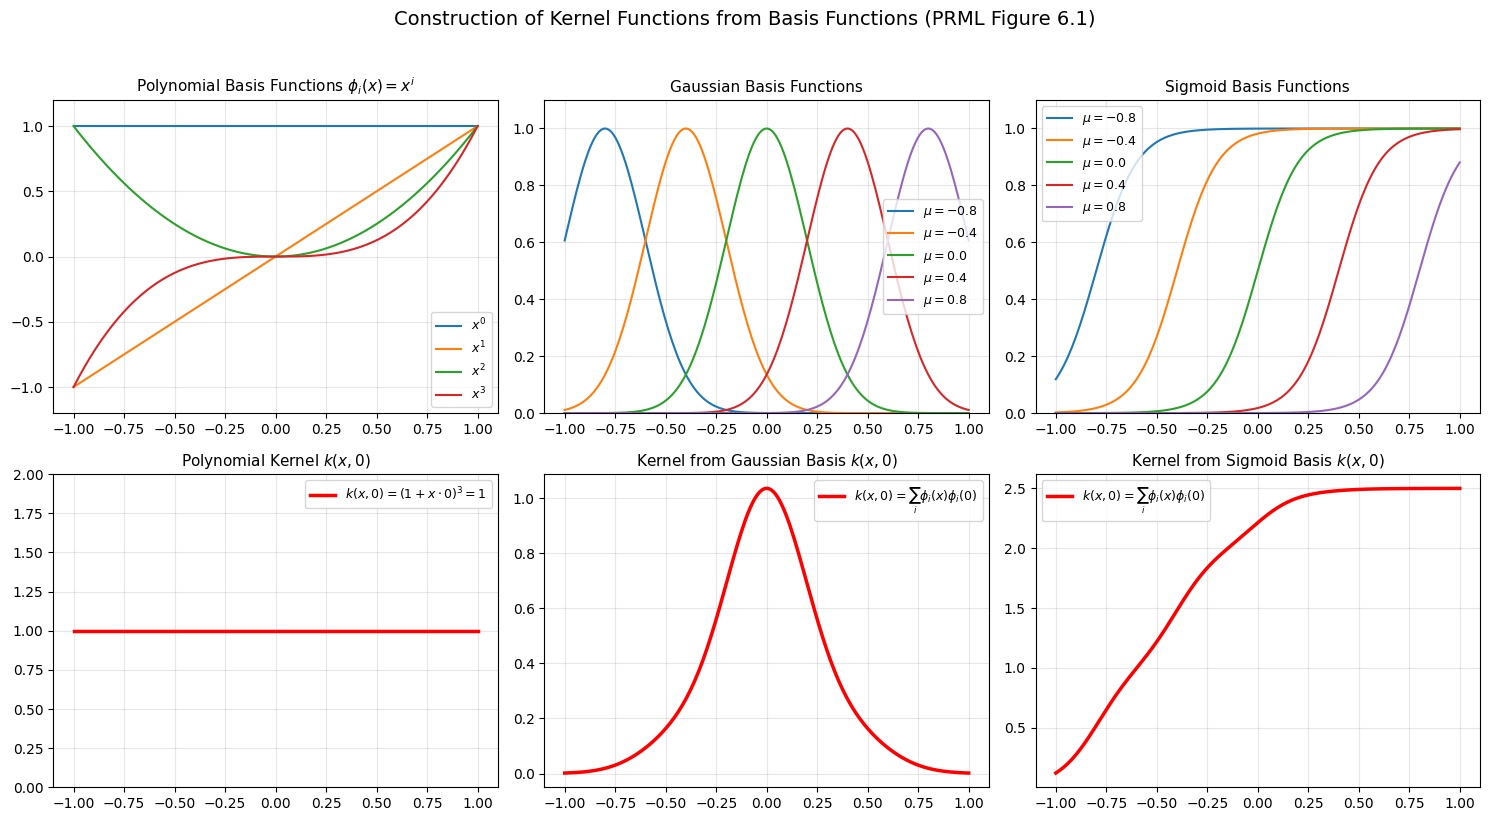

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.classification_utils import sigmoid
setup_style()

# PRML Figure 6.1 の完全再現
x = np.linspace(-1, 1, 200)
x_prime = 0.0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. 多項式基底 phi_i(x) = x^i
degrees = [0, 1, 2, 3]
for d in degrees:
    axes[0, 0].plot(x, x**d, label=rf'$x^{d}$')
axes[0, 0].set_title('Polynomial Basis Functions $\phi_i(x) = x^i$', fontsize=11)
axes[0, 0].set_ylim(-1.2, 1.2); axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend(fontsize=9)

# 多項式カーネル k(x, 0) = sum_i phi_i(x) phi_i(0)
# phi_i(0) = 1 (i=0), 0 (i>0) -> k(x, 0) = 1
# 一般に重み付き (1 + x x')^d の形
k_poly = (1.0 + x * x_prime)**3
axes[1, 0].plot(x, k_poly, 'r-', lw=2.5, label=r'$k(x, 0) = (1 + x \cdot 0)^3 = 1$')
axes[1, 0].set_title('Polynomial Kernel $k(x, 0)$', fontsize=11)
axes[1, 0].set_ylim(0, 2); axes[1, 0].grid(True, alpha=0.3); axes[1, 0].legend(fontsize=9)

# 2. ガウス基底 phi_i(x) = exp(-(x - mu_i)^2 / (2 s^2))
mus = np.linspace(-0.8, 0.8, 5)
s = 0.2
phi_gauss = np.zeros((len(x), len(mus)))
phi_gauss_prime = np.zeros(len(mus))
for i, mu in enumerate(mus):
    phi_gauss[:, i] = np.exp(-0.5 * (x - mu)**2 / s**2)
    phi_gauss_prime[i] = np.exp(-0.5 * (x_prime - mu)**2 / s**2)
    axes[0, 1].plot(x, phi_gauss[:, i], label=rf'$\mu={mu:.1f}$')
axes[0, 1].set_title('Gaussian Basis Functions', fontsize=11)
axes[0, 1].set_ylim(0, 1.1); axes[0, 1].grid(True, alpha=0.3); axes[0, 1].legend(fontsize=9)

# ガウスカーネル k(x, 0) = sum_i phi_i(x) phi_i(0)
k_gauss = phi_gauss @ phi_gauss_prime
axes[1, 1].plot(x, k_gauss, 'r-', lw=2.5, label=r'$k(x, 0) = \sum_i \phi_i(x)\phi_i(0)$')
axes[1, 1].set_title('Kernel from Gaussian Basis $k(x, 0)$', fontsize=11)
axes[1, 1].grid(True, alpha=0.3); axes[1, 1].legend(fontsize=9)

# 3. シグモイド基底 phi_i(x) = sigma((x - mu_i)/s)
phi_sig = np.zeros((len(x), len(mus)))
phi_sig_prime = np.zeros(len(mus))
for i, mu in enumerate(mus):
    phi_sig[:, i] = sigmoid((x - mu) / 0.1)
    phi_sig_prime[i] = sigmoid((x_prime - mu) / 0.1)
    axes[0, 2].plot(x, phi_sig[:, i], label=rf'$\mu={mu:.1f}$')
axes[0, 2].set_title('Sigmoid Basis Functions', fontsize=11)
axes[0, 2].set_ylim(0, 1.1); axes[0, 2].grid(True, alpha=0.3); axes[0, 2].legend(fontsize=9)

# シグモイドカーネル k(x, 0) = sum_i phi_i(x) phi_i(0)
k_sig = phi_sig @ phi_sig_prime
axes[1, 2].plot(x, k_sig, 'r-', lw=2.5, label=r'$k(x, 0) = \sum_i \phi_i(x)\phi_i(0)$')
axes[1, 2].set_title('Kernel from Sigmoid Basis $k(x, 0)$', fontsize=11)
axes[1, 2].grid(True, alpha=0.3); axes[1, 2].legend(fontsize=9)

plt.suptitle('Construction of Kernel Functions from Basis Functions (PRML Figure 6.1)', fontsize=14, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig6_1_kernel_construction.png')
plt.show()

Plot saved to: result/fig6_kernel_ridge_regression.png


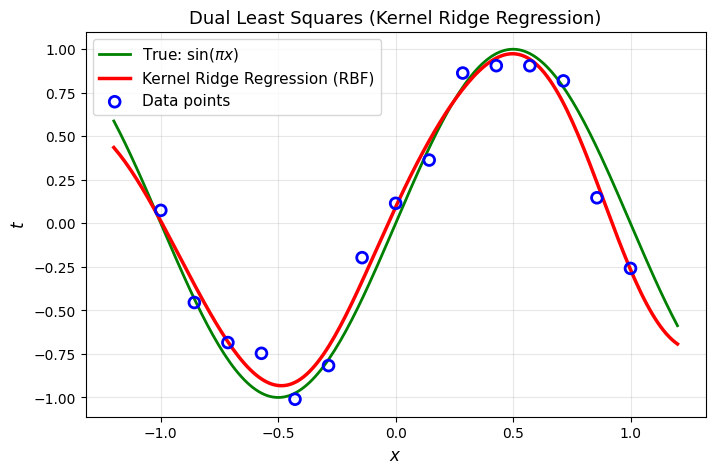

In [2]:
from common.kernel_utils import KernelRidgeRegression, rbf_kernel

# カーネルリッジ回帰による非線形回帰フィッティングの検証
np.random.seed(42)
N_pts = 15
X_train = np.linspace(-1, 1, N_pts).reshape(-1, 1)
t_train = np.sin(np.pi * X_train.ravel()) + np.random.normal(0, 0.15, N_pts)

X_test = np.linspace(-1.2, 1.2, 200).reshape(-1, 1)

krr = KernelRidgeRegression(kernel=rbf_kernel, reg_lambda=0.01, length_scale=0.4)
krr.fit(X_train, t_train)
y_pred = krr.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(X_test, np.sin(np.pi * X_test), 'g-', lw=2, label='True: $\sin(\pi x)$')
ax.plot(X_test, y_pred, 'r-', lw=2.5, label='Kernel Ridge Regression (RBF)')
ax.scatter(X_train, t_train, facecolors='none', edgecolors='b', s=60, lw=2, label='Data points', zorder=5)

ax.set_title('Dual Least Squares (Kernel Ridge Regression)', fontsize=13)
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$t$', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig6_kernel_ridge_regression.png')
plt.show()